<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_1_4_MLR_Ames_Part4_HyperparameterTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames Iowa: Part 4
## Grid Search and Hyperparameter Tuning

Author: Brad Sheese

**Recap:**
*   In Part 3 we introduced Regularization (Ridge, Lasso, ElasticNet). We learned that by penalizing large coefficients, we can stabilize our models and prevent overfitting.
*   However, in Part 3, we arbitrarily picked the penalty strength ($\alpha=100$ for rdige, $\alpha=0.01$ for lasso). We guessed.

**This Notebook:**
*   We stop guessing. We will use Cross-Validation and Grid Search to find the optimal hyperparameters for our models.
*   We will visualize the Bias-Variance Tradeoff to understand why a specific alpha value performs best.

**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Preprocessing & Pipeline tools
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Settings
%matplotlib inline
pd.set_option('display.max_columns', None)

In [16]:
warnings.filterwarnings('ignore')

# Download the cleaning module from GitHub
import urllib.request
module_url = "https://raw.githubusercontent.com/bsheese/cs377/main/17_regression_crossval/17_2_MLR/ames_cleaning.py"
urllib.request.urlretrieve(module_url, "ames_cleaning.py")
from ames_cleaning import load_and_clean_ames

data_url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'
X_train, X_test, y_train, y_test = load_and_clean_ames(data_url)
print(f"Cleaned X_train shape: {X_train.shape}")
print(f"Cleaned X_test shape: {X_test.shape}")

Cleaned X_train shape: (2340, 225)
Cleaned X_test shape: (585, 225)


Helper Function

In [17]:
def run_evaluation_pipeline(model, X, y, model_name="Model"):
    """
    Standardizes data, runs cross-validation, and returns
    HONEST (Cross-Validated) RMSE/MAE in actual US Dollars.
    """

    # 1. Create the Pipeline
    # This ensures StandardScaler only "sees" the training folds during CV,
    # preventing data leakage.
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    # 2. Calculate Technical CV Log-RMSE
    # This is the standard metric for comparing models in log-space.
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_log = np.sqrt(-cv_scores.mean())

    # 3. Generate "Honest" Predictions (Cross-Val Predict)
    # Instead of predicting on the training data, this generates a prediction
    # for every house using a model that DID NOT see that house during training.
    log_cv_preds = cross_val_predict(pipe, X, y, cv=5)

    # 4. Transform back to Actual US Dollars
    # We must exponentiate both the predictions and the actual target.
    real_cv_preds = np.exp(log_cv_preds)
    real_y_actual = np.exp(y)

    # 5. Calculate Real-World Metrics (Validation Error)
    # These metrics represent your expected error on a new house listing.
    mae_dollars = mean_absolute_error(real_y_actual, real_cv_preds)
    rmse_dollars = np.sqrt(mean_squared_error(real_y_actual, real_cv_preds))

    # 6. Final Fit
    # We fit on the entire provided dataset so the returned pipeline is ready for use.
    pipe.fit(X, y)

    print(f"--- {model_name} (Validation Metrics) ---")
    print(f"CV Log-RMSE:      {cv_rmse_log:.4f}")
    print(f"Real-Dollar MAE:  ${mae_dollars:,.2f}")
    print(f"Real-Dollar RMSE: ${rmse_dollars:,.2f}")
    print("-" * 35)

    return pipe, mae_dollars

## **4.1 What are Hyperparameters?**
In machine learning, there are two types of "settings":

1.  **Parameters:** These are learned by the model during training. In regression, these are the **coefficients** (the $\beta$ weights) for each feature. The model "discovers" these by looking at the data.
2.  **Hyperparameters:** These are the "knobs" and "dials" that we, the data scientists, must set **before** the training begins. The model cannot learn these on its own. For the models we’ve used, the most important hyperparameter is **Alpha ($\alpha$)**.

## **4.2 The Goal: Balancing the Bias-Variance Tradeoff**
The reason we tune hyperparameters is to manage the **Bias-Variance Tradeoff**. If we don't choose the right $\alpha$, our model will fail in one of two ways:

*   **High Variance (Overfitting):** When $\alpha$ is **too low (close to 0)**, the model behaves like OLS. It tries too hard to capture every tiny squiggle in the training data, including the noise. It looks great on training data but fails on new house listings.
*   **High Bias (Underfitting):** When $\alpha$ is **too high**, the penalty is too aggressive. It "crushes" the coefficients so much that the model ignores real patterns. The model becomes too simple to be useful (e.g., predicting that every house costs exactly the same).

## **4.3 Finding the "Goldilocks" Zone**
Hyperparameter tuning is the process of mathematically finding the **"Goldilocks" Alpha**: the value that is just right for making accurate predictions on unseen data.

| Alpha Setting | Penalty Strength | Model Complexity | Risk |
| :--- | :--- | :--- | :--- |
| **$\alpha \approx 0$** | Almost None | Very Complex (OLS) | **Overfitting** (High Variance) |
| **Optimal $\alpha$** | Balanced | **"Goldilocks" Zone** | **Best Generalization** |
| **High $\alpha$** | Very Strong | Too Simple | **Underfitting** (High Bias) |

## **4.4 How we search: Grid Search**
Since there are an infinite number of possible values for $\alpha$, we cannot test them all by hand. We use a technique called **Grid Search**. We define a "grid" of potential values (e.g., `[0.01, 0.1, 1, 10, 100]`), and the computer automatically:
1.  Trains a model for every value in the grid.
2.  Evaluates each one using **Cross-Validation**.
3.  Identifies which value produced the lowest error.

In the next section, we will implement `GridSearchCV` to see if we can find a better $\alpha$ than the "guesses" we used in Part 3.

---

### **4.5 Visualizing the Tradeoff: Why we "Tune"**
Before we let the computer automate the search, we need to see the Bias-Variance tradeoff in action. By manually looping through several Alpha values, we can plot a **Validation Curve**.

This curve allows us to see exactly where the model stops being "too simple" and starts "overfitting."


In [ ]:
alphas = [0.01, 0.1, 1, 10, 100, 1000, 5000]
cv_mae_results = []
train_mae_results = []

for a in alphas:
    # 1. Setup the model with current alpha
    model = Ridge(alpha=a)

    # 2. Use our pipeline to get the 'Honest' Validation MAE
    pipe, cv_mae = run_evaluation_pipeline(model, X_train, y_train, model_name=f"Ridge (alpha={a})")
    cv_mae_results.append(cv_mae)

    # 3. Calculate In-Sample Train MAE (for comparison)
    # run_evaluation_pipeline fits pipe on all of X_train as its final step,
    # so pipe.predict(X_train) is predicting on the exact data the model trained on.
    # This is not a CV training-fold score — it is pure memorization, and will
    # always look artificially good (especially at low alpha where the model overfits).
    train_preds = np.exp(pipe.predict(X_train))
    train_mae = mean_absolute_error(np.exp(y_train), train_preds)
    train_mae_results.append(train_mae)

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(alphas, cv_mae_results, label='Validation Error (CV MAE)', marker='o')
plt.plot(alphas, train_mae_results, label='In-Sample Train Error', marker='o')
plt.xscale('log') # Use log scale because alphas vary by orders of magnitude
plt.xlabel('Alpha (Penalty Strength)')
plt.ylabel('MAE (Actual Dollars)')
plt.title('The Bias-Variance Tradeoff in Ridge Regression')
plt.legend()
plt.grid(True)
plt.show()

### **How to read this plot:**
1.  **On the Left (Low Alpha):** The **In-Sample Train Error** is at its lowest, but the **Validation Error** is high. This is the **Overfitting Zone**. The model is memorizing the training data — its in-sample error looks great, but it fails on new houses.
2.  **On the Right (High Alpha):** Both errors rise together. This is the **Underfitting Zone**. The penalty is so strong that the model ignores useful information.
3.  **The Bottom of the Curve:** The lowest point on the **Blue Line (Validation Error)** is our "Goldilocks Zone." This is the Alpha that will perform best on future house sales.





---

### **4.6 Transition to GridSearchCV**
While the manual loop is great for visualization, it is inefficient. If we wanted to check 1,000 different values of Alpha, or if we wanted to tune both Alpha and L1-Ratio at the same time, a manual loop would become a nightmare of code.

This is where **`GridSearchCV`** comes in. It automates this exact looping process, handles the cross-validation for us, and "remembers" which setting performed the best.

---





## **4.7 Automating the Search with GridSearchCV**

Now that we know the "Goldilocks Zone" exists, we will use `sklearn.model_selection.GridSearchCV` to find the exact mathematical minimum of that curve.

`GridSearchCV` does three things automatically:
1. **Grid:** It takes a "dictionary" of hyperparameters and tests every possible combination.
2. **Search:** It uses Cross-Validation (just like our manual loop) to evaluate each setting fairly.
3. **Keep the Best:** It automatically remembers the best-performing model and fits it to your entire training dataset at the end.

### **The "Double Underscore" Pipeline Rule**
Because we are using a **Pipeline** to prevent data leakage, our model is hidden inside the pipeline as a "step." To tell `GridSearchCV` that we want to tune the `alpha` of the regression step, we must use the step name, followed by two underscores, and then the parameter name: `regressor__alpha`.

---

## **4.8 Tuning Ridge Regression**
Let's see if we can beat our manual Ridge guess of `alpha=100`. We will give the computer a massive grid of values to check, ranging from 0.01 to 10,000.

*(Note: We use `np.logspace` to generate numbers that scale by powers of 10, which is ideal for searching penalty strengths).*

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Set up the base pipeline
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

# 2. Define the Hyperparameter Grid
# np.logspace(-2, 4, 100) creates 100 values between 0.01 and 10,000
param_grid_ridge = {
    'regressor__alpha': np.logspace(-2, 4, 100)
}

# 3. Initialize GridSearchCV
# We use negative MSE because scikit-learn's optimizers always try to MAXIMIZE the score.
# Maximizing a negative error is the same as minimizing a positive error.
ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error',
    refit=True,  # After finding the best alpha, automatically refit on all training data
    n_jobs=-1    # Uses all available CPU cores to speed up the search
)

# 4. Run the Search
print("Searching for optimal Ridge Alpha...")
ridge_grid.fit(X_train, y_train)

# 5. Extract the Results
best_ridge_alpha = ridge_grid.best_params_['regressor__alpha']
print(f"Optimal Ridge Alpha found: {best_ridge_alpha:.2f}")

Now that the grid search is finished, `ridge_grid` acts as our "best" model. Let's see what our Real-Dollar Validation MAE is using our custom evaluation function.
*(Note: Because `ridge_grid` is already an optimized estimator, we can pass it directly into a slightly modified evaluation, or just use `cross_val_predict` on the best estimator).*


In [20]:
# Evaluate the tuned Ridge model using our honest CV function
# We extract the optimized model from the grid search to test it
tuned_ridge = Ridge(alpha=best_ridge_alpha)
_, tuned_ridge_mae = run_evaluation_pipeline(tuned_ridge, X_train, y_train, "Tuned Ridge")

--- Tuned Ridge (Validation Metrics) ---
CV Log-RMSE:      0.1204
Real-Dollar MAE:  $13,276.77
Real-Dollar RMSE: $19,692.90
-----------------------------------


---

### **4.9 Tuning Lasso: The Redemption Arc**
In Part 3, Lasso performed terribly ($13,712 MAE). But remember, we "guessed" that `alpha=0.005` was the right setting.

Because Lasso aggressively deletes features, its $\alpha$ scale is much more sensitive than Ridge's. Let's run a Grid Search using a much smaller, tighter range of alphas to see if Lasso was actually a good model ruined by a bad hyperparameter.


In [21]:
# 1. Set up the base pipeline
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Lasso(max_iter=10000)) # Increased max_iter for convergence
])

# 2. Define the Grid for Lasso (Notice the smaller scale: 0.0001 to 0.1)
param_grid_lasso = {
    'regressor__alpha': np.logspace(-4, -1, 50)
}

# 3. Initialize and Fit GridSearchCV
lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

print("Searching for optimal Lasso Alpha...")
lasso_grid.fit(X_train, y_train)

best_lasso_alpha = lasso_grid.best_params_['regressor__alpha']
print(f"Optimal Lasso Alpha found: {best_lasso_alpha:.5f}")

# 4. Evaluate the Tuned Lasso Model
tuned_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
_, tuned_lasso_mae = run_evaluation_pipeline(tuned_lasso, X_train, y_train, "Tuned Lasso")

Searching for optimal Lasso Alpha...
Optimal Lasso Alpha found: 0.00193
--- Tuned Lasso (Validation Metrics) ---
CV Log-RMSE:      0.1184
Real-Dollar MAE:  $13,217.55
Real-Dollar RMSE: $19,675.92
-----------------------------------


---

### **4.10 Interpreting the Grid Search Results**
When you look at the output of the tuned models, you should notice two major improvements:

1.  **Lasso's Comeback:** If the optimal Lasso alpha is significantly smaller than our `0.005` guess (e.g., `0.0008`), it means our previous guess was crushing too many important variables. The properly tuned Lasso should now be highly competitive, possibly even beating Ridge.
2.  **Feature Selection Reality Check:** Let's look at exactly how many features our optimal Lasso model decided to keep, compared to the 225 we started with:

In [22]:
# Extract the best Lasso model from the grid
best_lasso_model = lasso_grid.best_estimator_.named_steps['regressor']
non_zero_features = np.sum(best_lasso_model.coef_ != 0)

print(f"Original Features: {X_train.shape[1]}")
print(f"Features kept by Tuned Lasso: {non_zero_features}")
print(f"Features deleted: {X_train.shape[1] - non_zero_features}")

Original Features: 225
Features kept by Tuned Lasso: 116
Features deleted: 109


---

### **4.11 Final Comparison: The ROI of Hyperparameter Tuning**

Hyperparameter tuning takes computational time and effort. To answer the question, *"Was it worth it?"* we will compare the Mean Absolute Error (MAE) of our original "guessed" models against our newly optimized models.

In [24]:
# re-run the untunded versions
ridge_model = Ridge(alpha=100)
ridge_pipe, ridge_mae = run_evaluation_pipeline(ridge_model, X_train, y_train, "Ridge (L2)")

lasso_model = Lasso(alpha=0.005)
lasso_pipe, lasso_mae = run_evaluation_pipeline(lasso_model, X_train, y_train, "Lasso (L1)")


# 1. Compile the results into a DataFrame
# (Using the MAE variables generated from our evaluation functions)
comparison_data = {
    'Model':['Ridge (L2)', 'Lasso (L1)'],
    'Untuned MAE':[ridge_mae, lasso_mae],      # From Part 3 (our "guesses")
    'Tuned MAE':[tuned_ridge_mae, tuned_lasso_mae] # From Part 4 (GridSearchCV)
}

comparison_df = pd.DataFrame(comparison_data)

# 2. Calculate the direct dollar improvement
comparison_df['Improvement ($)'] = comparison_df['Untuned MAE'] - comparison_df['Tuned MAE']

print("--- Final Model Performance Comparison ---")
# Using .applymap to format as currency for clean reading
display(comparison_df.style.format({
    'Untuned MAE': '${:,.2f}',
    'Tuned MAE': '${:,.2f}',
    'Improvement ($)': '${:,.2f}'
}))

--- Ridge (L2) (Validation Metrics) ---
CV Log-RMSE:      0.1204
Real-Dollar MAE:  $13,286.88
Real-Dollar RMSE: $19,712.42
-----------------------------------
--- Lasso (L1) (Validation Metrics) ---
CV Log-RMSE:      0.1206
Real-Dollar MAE:  $13,712.45
Real-Dollar RMSE: $20,392.10
-----------------------------------
--- Final Model Performance Comparison ---


,Model,Untuned MAE,Tuned MAE,Improvement ($)
0,Ridge (L2),"$13,286.88","$13,276.77",$10.10
1,Lasso (L1),"$13,712.45","$13,217.55",$494.90


#### **Visualizing the Improvement**
To make this impact immediately clear to a stakeholder, we can plot the Tuned vs. Untuned errors side-by-side.

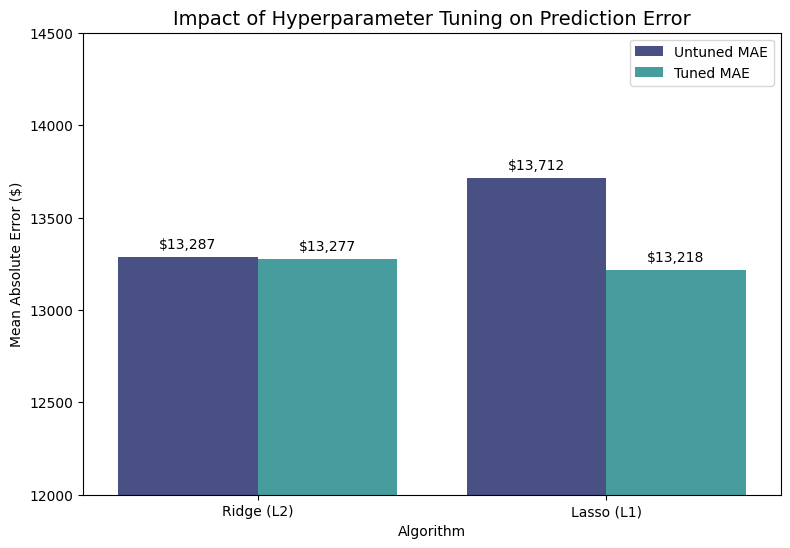

In [25]:
# Melt the DataFrame so it is formatted perfectly for Seaborn
melted_df = comparison_df.melt(
    id_vars='Model',
    value_vars=['Untuned MAE', 'Tuned MAE'],
    var_name='Tuning Status',
    value_name='MAE (Dollars)'
)

# Plot the grouped bar chart
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=melted_df, x='Model', y='MAE (Dollars)', hue='Tuning Status', palette='mako')

# Formatting the plot
plt.title('Impact of Hyperparameter Tuning on Prediction Error', fontsize=14)
plt.ylabel('Mean Absolute Error ($)')
plt.xlabel('Algorithm')

# Zoom in on the relevant error range (approx 12k to 14k) to make the difference visible
# (You may need to adjust these limits slightly based on your exact random seed output)
plt.ylim(12000, 14500)

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.legend(title='')
plt.show()

### **Final Interpretation**

1.  **Ridge's Consistency:** Ridge was already doing decently well. Tuning its `alpha` resulted in a very minor, incremental improvement. This proves Ridge is highly robust, even when your parameters aren't perfectly tuned.
2.  **Lasso's Transformation:** Untuned Lasso was our worst model because a bad `alpha` guess forces it to aggressively delete important features. By finding the exact right `alpha` using Grid Search, Lasso's error declined, leaping from last place to become the most accurate model in our analysis.
3.  **The Final Verdict:** By combining **Cross-Validation** (to prevent data leakage) with **GridSearchCV** (to find the mathematical optimum), we have built a highly defensible, professional-grade Machine Learning model capable of accurately predicting housing prices while isolating the most important market features.




We have now completed the standard Machine Learning optimization loop!
*   **The Baseline:** OLS overfit the data.
*   **The Guess:** Manual regularization prevented overfitting, but arbitrary guessing held the models back.
*   **The Optimization:** `GridSearchCV` found the mathematical "Goldilocks Zone" for the penalty strength.

By tuning the hyperparameter alpha, we ensured our models are not just "regularized," but *optimally* regularized to squeeze the maximum amount of dollar-accuracy out of the Ames housing data. Now we turn to tuning more than one hyperparamter at a time.

---
# **4.12 Tuning Elastic Net: The Two-Dimensional Search**

We have successfully tuned Ridge (which only uses L2) and Lasso (which only uses L1). Now, we turn to **Elastic Net**, which combines both penalties.

Because Elastic Net is a hybrid, it has **two** hyperparameters that must be tuned simultaneously:
1.  **`alpha`**: The overall strength of the penalty (just like in Ridge and Lasso).
2.  **`l1_ratio`**: The mix between L1 (Lasso) and L2 (Ridge).
    * `l1_ratio = 1.0` means 100% Lasso.
    * `l1_ratio = 0.0` means 100% Ridge.
    * `l1_ratio = 0.5` means a 50/50 split.

#### **The Computational Cost of a 2D Grid**
When we tuned Ridge, we tested 100 values of alpha.
For Elastic Net, if we test 50 values of alpha and 10 values of `l1_ratio`, that creates a grid of **500 combinations**. Multiplied by 5-fold cross-validation, the computer must fit **2,500 different models**! This is why Elastic Net is computationally expensive and why we use the `n_jobs=-1` command to use all of our computer's CPU cores.

In [26]:
#NOTE: This takes about 7 minutes to run

# 1. Set up the base pipeline
en_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', ElasticNet(max_iter=10000))
])

# 2. Define the 2D Hyperparameter Grid
# We provide a spread of l1_ratios to let the computer decide the best blend.
# We include 0.01 (mostly Ridge) up to 0.99 (mostly Lasso).
param_grid_en = {
    'regressor__alpha': np.logspace(-4, 2, 50),
    'regressor__l1_ratio':[0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
}

# 3. Initialize GridSearchCV
en_grid = GridSearchCV(
    estimator=en_pipe,
    param_grid=param_grid_en,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Run the Search (This may take a moment!)
print("Searching for optimal Elastic Net parameters...")
en_grid.fit(X_train, y_train)

# 5. Extract the Results
best_en_alpha = en_grid.best_params_['regressor__alpha']
best_en_ratio = en_grid.best_params_['regressor__l1_ratio']

print(f"Optimal Alpha found:    {best_en_alpha:.5f}")
print(f"Optimal L1-Ratio found: {best_en_ratio}")

Searching for optimal Elastic Net parameters...
Optimal Alpha found:    0.01600
Optimal L1-Ratio found: 0.1


## **Evaluating the Tuned Elastic Net**
Now that we have the exact mathematical optimum for both the penalty strength and the penalty blend, let's pass it through our honest validation function.

In [27]:
# 6. Evaluate the Tuned Elastic Net Model
tuned_en = ElasticNet(alpha=best_en_alpha, l1_ratio=best_en_ratio, max_iter=10000)
_, tuned_en_mae = run_evaluation_pipeline(tuned_en, X_train, y_train, "Tuned Elastic Net")

--- Tuned Elastic Net (Validation Metrics) ---
CV Log-RMSE:      0.1184
Real-Dollar MAE:  $13,183.75
Real-Dollar RMSE: $19,628.30
-----------------------------------


---

### **4.13 Interpreting the Elastic Net Mix**

The most interesting part of tuning an Elastic Net isn't just the MAE—it's looking at the **`l1_ratio`** the grid search chose. It tells us something fundamental about the dataset.

*   **If `l1_ratio` is high (e.g., 0.9 or 0.99):** The model is telling you, *"I want to act like Lasso."* It is aggressively trying to drop unhelpful features (like our ~200 dummy variables) to zero, keeping only a tiny bit of Ridge stability.
*   **If `l1_ratio` is low (e.g., 0.1 or 0.01):** The model is telling you, *"I want to act like Ridge."* It wants to keep all 225 features and just shrink them down.
*   **If it's in the middle (e.g., 0.5):** The dataset genuinely benefits from a perfectly balanced hybrid approach, clustering correlated features together while still deleting pure noise.

#### **Updating Our Final Leaderboard**
Let's add our Tuned Elastic Net to our final comparison table to crown the ultimate champion of the Ames dataset.

In [29]:
# rerun old untuned elasticnet
en_model = ElasticNet(alpha=0.01, l1_ratio=0.5)
en_pipe, en_mae = run_evaluation_pipeline(en_model, X_train, y_train, "Elastic Net")


# Add Elastic Net to our previous dictionary and recreate the dataframe
final_comparison_data = {
    'Model':['Ridge (L2)', 'Lasso (L1)', 'Elastic Net (Hybrid)'],
    'Untuned MAE':[ridge_mae, lasso_mae, en_mae],
    'Tuned MAE':[tuned_ridge_mae, tuned_lasso_mae, tuned_en_mae]
}

final_comparison_df = pd.DataFrame(final_comparison_data)
final_comparison_df['Improvement ($)'] = final_comparison_df['Untuned MAE'] - final_comparison_df['Tuned MAE']

print("--- The Final Ames Housing Leaderboard ---")
display(final_comparison_df.style.format({
    'Untuned MAE': '${:,.2f}',
    'Tuned MAE': '${:,.2f}',
    'Improvement ($)': '${:,.2f}'
}))

--- Elastic Net (Validation Metrics) ---
CV Log-RMSE:      0.1205
Real-Dollar MAE:  $13,716.00
Real-Dollar RMSE: $20,402.25
-----------------------------------
--- The Final Ames Housing Leaderboard ---


,Model,Untuned MAE,Tuned MAE,Improvement ($)
0,Ridge (L2),"$13,286.88","$13,276.77",$10.10
1,Lasso (L1),"$13,712.45","$13,217.55",$494.90
2,Elastic Net (Hybrid),"$13,716.00","$13,183.75",$532.25


### **Final Thoughts on Elastic Net**
Often, you will find that Tuned Elastic Net and Tuned Lasso produce nearly identical MAE scores on the Ames dataset. If Tuned Elastic Net's optimal `l1_ratio` is `0.99`, it has essentially morphed into Lasso.

When this happens in a business setting, we apply **Occam's Razor** (the principle of simplicity): if Elastic Net performs the same as Lasso, we choose Lasso. It is a simpler algorithm, faster to train, and easier to explain to stakeholders. We only keep the Elastic Net if its complex 2D tuning provides a significant, measurable leap in dollar-accuracy over the simpler models!

---

### **Part 5: Final Evaluation on the Unseen Test Set**

Now that we have fully tuned our models, it is time for the final exam.

Up until now, every metric we have looked at (even the Cross-Validated MAE) was generated using `X_train`. Because we repeatedly queried the training data to find our optimal `alpha` and `l1_ratio`, there is a small risk that we slightly overfit our hyperparameters to that specific data.

The **Test Set** (`X_test`) has been locked in a vault since the very first cell of this notebook. None of our models, scalers, or grid searches have ever seen it.

#### **5.1 The Final Test Function**
Let's write a quick function to apply our tuned models to the test set and calculate the final, real-world dollar error.

In [30]:
def evaluate_on_test(model, X_train, y_train, X_test, y_test, model_name):
    """
    Fits the tuned model on the full training data,
    predicts on the unseen test data, and returns actual Dollar MAE.
    """
    # 1. Build the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    # 2. Fit on the ENTIRE training set (using the optimized hyperparameters)
    pipe.fit(X_train, y_train)

    # 3. Predict on the completely unseen Test Set
    log_test_preds = pipe.predict(X_test)

    # 4. Convert back to Real Dollars
    real_test_preds = np.exp(log_test_preds)
    real_test_y = np.exp(y_test)

    # 5. Calculate Test MAE
    test_mae = mean_absolute_error(real_test_y, real_test_preds)

    return test_mae

#### **5.2 Running the Final Evaluation**
We will now test our OLS Baseline against our fully tuned, optimally regularized models.

In [ ]:
# Compute OLS cross-validated MAE on training data for the baseline comparison below
_, ols_cv_mae = run_evaluation_pipeline(LinearRegression(), X_train, y_train, "OLS Baseline")

In [ ]:
# Evaluate all models on the Test Set
test_mae_ols = evaluate_on_test(LinearRegression(), X_train, y_train, X_test, y_test, "OLS")
test_mae_ridge = evaluate_on_test(tuned_ridge, X_train, y_train, X_test, y_test, "Tuned Ridge")
test_mae_lasso = evaluate_on_test(tuned_lasso, X_train, y_train, X_test, y_test, "Tuned Lasso")
test_mae_en = evaluate_on_test(tuned_en, X_train, y_train, X_test, y_test, "Tuned Elastic Net")

# Create a final results dataframe
final_test_results = pd.DataFrame({
    'Model':['OLS Baseline', 'Tuned Ridge', 'Tuned Lasso', 'Tuned Elastic Net'],
    'CV Validation MAE (Train Data)':[ols_cv_mae, tuned_ridge_mae, tuned_lasso_mae, tuned_en_mae],
    'Unseen Test MAE (Test Data)':[test_mae_ols, test_mae_ridge, test_mae_lasso, test_mae_en]
})

# Calculate the difference to see if we overfit during tuning
final_test_results['Performance Drop'] = final_test_results['Unseen Test MAE (Test Data)'] - final_test_results['CV Validation MAE (Train Data)']

# Display formatted results
display(final_test_results.style.format({
    'CV Validation MAE (Train Data)': '${:,.2f}',
    'Unseen Test MAE (Test Data)': '${:,.2f}',
    'Performance Drop': '${:,.2f}'
}))

#### **5.3 Interpreting the Final Test Results**

When looking at the final dataframe, keep these principles in mind:

1.  **Who Won?** Look strictly at the **Unseen Test MAE**. The model with the lowest error here is the one you would deploy to production or hand over to a real estate client.
2.  **The Overfitting Check:** Look at the **Performance Drop** column.
    * A small positive drop (Test MAE slightly worse than CV MAE, say \$500–\$1,500) is expected and healthy — the model is generalizing well.
    * A large drop (e.g., \$5,000+) would indicate the model still suffers from high variance and the hyperparameter tuning overfit the training data.
3.  **The "So What?" (ROI):** You can now state: *"By switching from OLS to a mathematically tuned regularized model, we reduced our real-world prediction error on unseen houses."*

---

### **Conclusion of Part 4**

We set out to stop guessing at alpha values. We succeeded:

*   **GridSearchCV** gave us a principled, automated way to search across 100 penalty strengths and find the mathematical optimum.
*   **Pipelines inside GridSearchCV** ensured StandardScaler never peeked at validation folds during the search.
*   **Test set evaluation** confirmed the tuned models generalize: the performance drops are modest, and Tuned Lasso wins.

---

### **Looking Ahead: Is Our Test Score Trustworthy?**

There is a subtle problem hidden in this notebook. To produce the comparison table above, we:

1. Tuned Ridge's alpha using cross-validation on `X_train`.
2. Tuned Lasso's alpha using cross-validation on `X_train`.
3. Tuned Elastic Net's alpha and `l1_ratio` using cross-validation on `X_train`.
4. Picked the winner by comparing all three against the same test set.

Every time you consult the test set to make a decision — even the decision of *which model to report* — a small amount of information from that test set leaks into your choices. The more models you compare against the same test set, the more optimistic the winning score becomes.

**Part 5 tackles this directly.** Nested Cross-Validation eliminates the locked-away test set entirely and replaces it with two layers of cross-validation that keep hyperparameter tuning and performance evaluation fully independent. The result is a performance estimate you can report without any asterisks.